# IBM HR Analytics — Employee Attrition Analysis

## Project Overview

This project analyzes employee attrition using the IBM HR Analytics Employee Attrition dataset.

The objective is to explore employee demographics, job characteristics, compensation, work conditions, satisfaction, and tenure to identify patterns associated with employee attrition.

### Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Google Colab

### Dataset

The dataset contains 1,470 employee records and 35 attributes describing employee demographics, job characteristics, compensation, satisfaction, and employment history.

### Objective

The analysis aims to answer:

> **What employee and workplace factors are associated with employee attrition, and what insights can HR teams derive from these patterns?**


## Business Problem

Employee attrition can increase recruitment costs, reduce workforce stability, and result in the loss of experienced employees.

The objective of this analysis is to identify patterns in employee attrition and determine which employee, job, compensation, and workplace characteristics are associated with higher attrition rates.

### Key Business Questions

The analysis investigates:

1. What is the overall employee attrition rate?
2. Which departments have higher attrition?
3. Which job roles have higher attrition?
4. Is overtime associated with higher attrition?
5. How does attrition vary across age groups?
6. How does tenure relate to attrition?
7. Does job satisfaction differ across employees who stay and leave?
8. Does work-life balance show differences in attrition?
9. Does monthly income differ between employees who stay and leave?
10. Which numerical variables are strongly correlated with each other?


# 1. Import the Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. Understand the Dataset


In [7]:
df.head()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,BusinessTravel,...,JobSatisfaction,WorkLifeBalance,PerformanceRating,JobInvolvement,Attrition,EmployeeNumber,EmployeeCount,StandardHours,Over18,DailyRate
0,41,Female,Single,2,Life Sciences,1,Sales,Sales Executive,2,Travel_Rarely,...,4,1,3,3,Yes,1,1,80,Y,1102
1,49,Male,Married,1,Life Sciences,8,Research & Development,Research Scientist,2,Travel_Frequently,...,2,3,4,2,No,2,1,80,Y,279
2,37,Male,Single,2,Other,2,Research & Development,Laboratory Technician,1,Travel_Rarely,...,3,3,3,2,Yes,4,1,80,Y,1373
3,33,Female,Married,4,Life Sciences,3,Research & Development,Research Scientist,1,Travel_Frequently,...,3,3,3,3,No,5,1,80,Y,1392
4,27,Male,Married,1,Medical,2,Research & Development,Laboratory Technician,1,Travel_Rarely,...,2,3,3,3,No,7,1,80,Y,591


In [8]:
print (df.shape)
print ('Rows :' , df.shape[0])
print ('Columns :' , df.shape[1])

(1470, 27)
Rows : 1470
Columns : 27


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Gender                   1470 non-null   object
 2   MaritalStatus            1470 non-null   object
 3   Education                1470 non-null   int64 
 4   EducationField           1470 non-null   object
 5   DistanceFromHome         1470 non-null   int64 
 6   Department               1470 non-null   object
 7   JobRole                  1470 non-null   object
 8   JobLevel                 1470 non-null   int64 
 9   BusinessTravel           1470 non-null   object
 10  OverTime                 1470 non-null   object
 11  YearsAtCompany           1470 non-null   int64 
 12  TotalWorkingYears        1470 non-null   int64 
 13  YearsInCurrentRole       1470 non-null   int64 
 14  MonthlyIncome            1470 non-null  

In [10]:
df.dtypes.value_counts()

,count
int64,18
object,9


In [11]:
df.describe()

,Age,Education,DistanceFromHome,JobLevel,YearsAtCompany,TotalWorkingYears,YearsInCurrentRole,MonthlyIncome,PercentSalaryHike,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,JobInvolvement,EmployeeNumber,EmployeeCount,StandardHours,DailyRate
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.0,1470.000000
mean,36.923810,2.912925,9.192517,2.063946,7.008163,11.279592,4.229252,6502.931293,15.209524,2.721769,2.728571,2.761224,3.153741,2.729932,1024.865306,1.0,80.0,802.485714
std,9.135373,1.024165,8.106864,1.106940,6.126525,7.780782,3.623137,4707.956783,3.659938,1.093082,1.102846,0.706476,0.360824,0.711561,602.024335,0.0,0.0,403.509100
min,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1009.000000,11.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.0,80.0,102.000000
25%,30.000000,2.000000,2.000000,1.000000,3.000000,6.000000,2.000000,2911.000000,12.000000,2.000000,2.000000,2.000000,3.000000,2.000000,491.250000,1.0,80.0,465.000000
50%,36.000000,3.000000,7.000000,2.000000,5.000000,10.000000,3.000000,4919.000000,14.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1020.500000,1.0,80.0,802.000000
75%,43.000000,4.000000,14.000000,3.000000,9.000000,15.000000,7.000000,8379.000000,18.000000,4.000000,4.000000,3.000000,3.000000,3.000000,1555.750000,1.0,80.0,1157.000000
max,60.000000,5.000000,29.000000,5.000000,40.000000,40.000000,18.000000,19999.000000,25.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2068.000000,1.0,80.0,1499.000000


In [12]:
df.describe(include='object')

,Gender,MaritalStatus,EducationField,Department,JobRole,BusinessTravel,OverTime,Attrition,Over18
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,6,3,9,3,2,2,1
top,Male,Married,Life Sciences,Research & Development,Sales Executive,Travel_Rarely,No,No,Y
freq,882,673,606,961,326,1043,1054,1233,1470


In [13]:
df['Age'].mean()

np.float64(36.923809523809524)

In [14]:
df['MonthlyIncome'].median()

4919.0

In [15]:
df['YearsAtCompany'].min()

0

In [16]:
df['YearsAtCompany'].max()

40

In [17]:
df['Department'].value_counts()

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


# 3. Missing Value Analysis

In [18]:
df.isnull().sum()

,0
Age,0
Gender,0
MaritalStatus,0
Education,0
EducationField,0
DistanceFromHome,0
Department,0
JobRole,0
JobLevel,0
BusinessTravel,0


In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.isnull().sum()/len(df)*100

,0
Age,0.0
Gender,0.0
MaritalStatus,0.0
Education,0.0
EducationField,0.0
DistanceFromHome,0.0
Department,0.0
JobRole,0.0
JobLevel,0.0
BusinessTravel,0.0


In [21]:
missing_summary= pd.DataFrame({
'missing values': df.isnull().sum(),
 'missing percenatge': df.isnull().sum()/len(df)*100
})
missing_summary

,missing values,missing percenatge
Age,0,0.0
Gender,0,0.0
MaritalStatus,0,0.0
Education,0,0.0
EducationField,0,0.0
DistanceFromHome,0,0.0
Department,0,0.0
JobRole,0,0.0
JobLevel,0,0.0
BusinessTravel,0,0.0


# 4. Checking Duplicate Records

In [22]:
duplicate_count=df.duplicated().sum()
print('Number of Duplicates :' , duplicate_count)

Number of Duplicates : 0


In [23]:
df['EmployeeNumber'].duplicated().sum()

np.int64(0)

In [24]:
df['EmployeeNumber'].nunique()

1470

In [25]:
print('Total Employee :', len(df))
print('total duplicate :', df['EmployeeNumber'].nunique())

Total Employee : 1470
total duplicate : 1470


# 5. Checking Unique Values & Categories

In [26]:
df['Attrition'].nunique()

2

In [27]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

In [28]:
df['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [29]:
df['JobRole'].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [30]:
df['Department'].value_counts()

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [31]:
df['Department'].value_counts(normalize=True)*100

,proportion
Department,
Research & Development,65.374150
Sales,30.340136
Human Resources,4.285714


In [32]:
department_summary = pd.DataFrame({
    'count': df['Department'].value_counts(),
    'percenetage': df['Department'].value_counts(normalize=True)*100
})
department_summary

,count,percenetage
Department,,
Research & Development,961,65.374150
Sales,446,30.340136
Human Resources,63,4.285714


In [33]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [34]:
df['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


In [35]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [36]:
df['JobSatisfaction'].unique()

array([4, 2, 3, 1])

In [37]:
df['JobSatisfaction'].value_counts()

,count
JobSatisfaction,
4,459
3,442
1,289
2,280


In [38]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [39]:
df['JobSatisfaction'].value_counts().sort_index()

,count
JobSatisfaction,
1,289
2,280
3,442
4,459


# 6. Basic Statistical Analysis

In [40]:
df.describe()

,Age,Education,DistanceFromHome,JobLevel,YearsAtCompany,TotalWorkingYears,YearsInCurrentRole,MonthlyIncome,PercentSalaryHike,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,JobInvolvement,EmployeeNumber,EmployeeCount,StandardHours,DailyRate
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.0,1470.000000
mean,36.923810,2.912925,9.192517,2.063946,7.008163,11.279592,4.229252,6502.931293,15.209524,2.721769,2.728571,2.761224,3.153741,2.729932,1024.865306,1.0,80.0,802.485714
std,9.135373,1.024165,8.106864,1.106940,6.126525,7.780782,3.623137,4707.956783,3.659938,1.093082,1.102846,0.706476,0.360824,0.711561,602.024335,0.0,0.0,403.509100
min,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1009.000000,11.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.0,80.0,102.000000
25%,30.000000,2.000000,2.000000,1.000000,3.000000,6.000000,2.000000,2911.000000,12.000000,2.000000,2.000000,2.000000,3.000000,2.000000,491.250000,1.0,80.0,465.000000
50%,36.000000,3.000000,7.000000,2.000000,5.000000,10.000000,3.000000,4919.000000,14.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1020.500000,1.0,80.0,802.000000
75%,43.000000,4.000000,14.000000,3.000000,9.000000,15.000000,7.000000,8379.000000,18.000000,4.000000,4.000000,3.000000,3.000000,3.000000,1555.750000,1.0,80.0,1157.000000
max,60.000000,5.000000,29.000000,5.000000,40.000000,40.000000,18.000000,19999.000000,25.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2068.000000,1.0,80.0,1499.000000


In [41]:
df[['Age', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsInCurrentRole',
    'DistanceFromHome']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
YearsInCurrentRole,1470.0,4.229252,3.623137,0.0,2.0,3.0,7.0,18.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0


In [42]:
age_range = df['Age'].max() - df['Age'].min()

print("Age range:", age_range)

Age range: 42


In [43]:
income_range = df['MonthlyIncome'].max() - df['MonthlyIncome'].min()

print("Monthly income range:", income_range)

Monthly income range: 18990


In [44]:
print("Mean age:", df['Age'].mean())
print("Median age:", df['Age'].median())
print("Minimum age:", df['Age'].min())
print("Maximum age:", df['Age'].max())

Mean age: 36.923809523809524
Median age: 36.0
Minimum age: 18
Maximum age: 60


In [45]:
print("Mean monthly income:", df['MonthlyIncome'].mean())
print("Median monthly income:", df['MonthlyIncome'].median())
print("Minimum monthly income:", df['MonthlyIncome'].min())
print("Maximum monthly income:", df['MonthlyIncome'].max())
print("Income standard deviation:", df['MonthlyIncome'].std())
print("Income skewness:", df['MonthlyIncome'].skew())

Mean monthly income: 6502.931292517007
Median monthly income: 4919.0
Minimum monthly income: 1009
Maximum monthly income: 19999
Income standard deviation: 4707.956783097995
Income skewness: 1.3698166808390662


In [46]:
print("Mean Total Working Years:", df['TotalWorkingYears'].mean())
print("Median Total Working Years:", df['TotalWorkingYears'].median())

Mean Total Working Years: 11.279591836734694
Median Total Working Years: 10.0


In [47]:
print("Mean Years at company:", df ['YearsAtCompany'].mean())
print("Median Years at company:", df ['YearsAtCompany'].median())

Mean Years at company: 7.0081632653061225
Median Years at company: 5.0


# 7. Employee Distribution Analysis

In [48]:
department_counts=df['Department'].value_counts()
department_counts

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [49]:
department_percentage=df['Department'].value_counts(normalize=True)*100
department_percentage

,proportion
Department,
Research & Development,65.374150
Sales,30.340136
Human Resources,4.285714


In [50]:
department_summary=pd.DataFrame({
    'Employee Count': df['Department'].value_counts(),
    'Employee Percentage': df['Department'].value_counts(normalize=True)*100
})
department_summary

,Employee Count,Employee Percentage
Department,,
Research & Development,961,65.374150
Sales,446,30.340136
Human Resources,63,4.285714


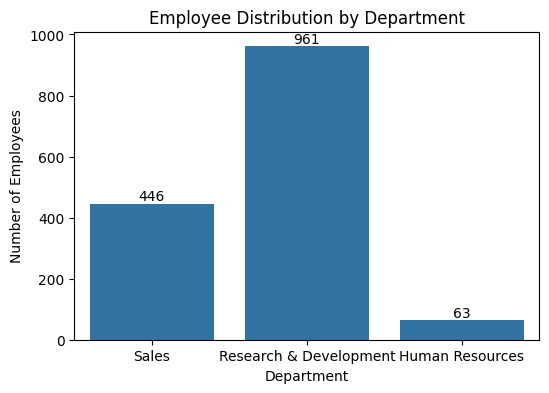

In [51]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='Department')

plt.title('Employee Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

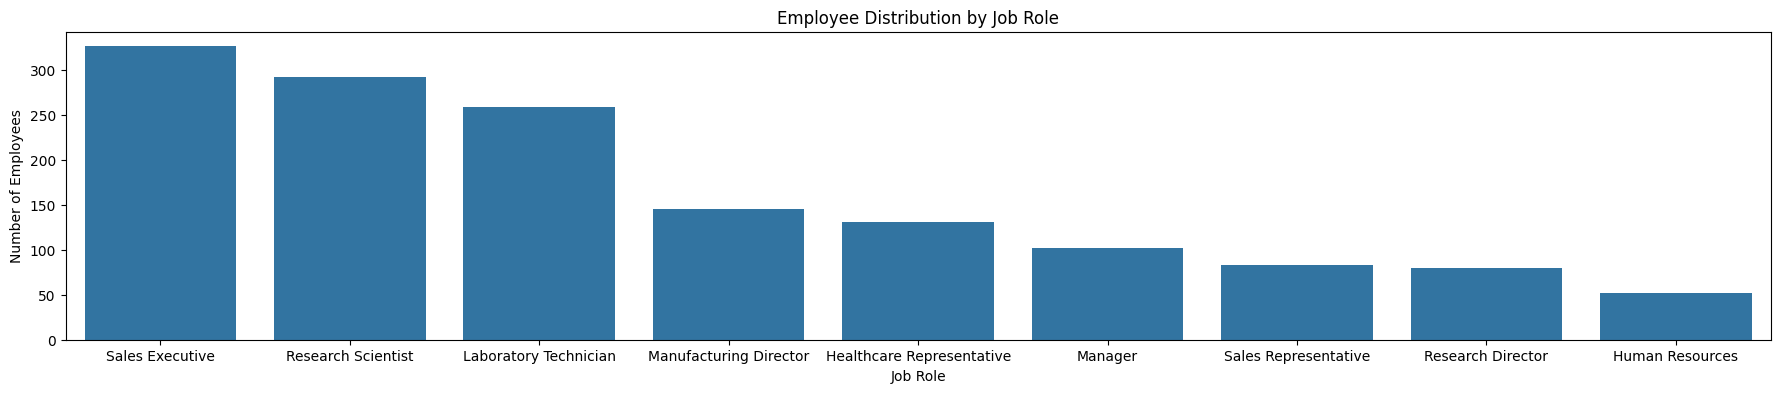

In [52]:
plt.figure(figsize=(22,4))
sns.countplot(data=df,x='JobRole')

plt.title('Employee Distribution by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')

plt.show()

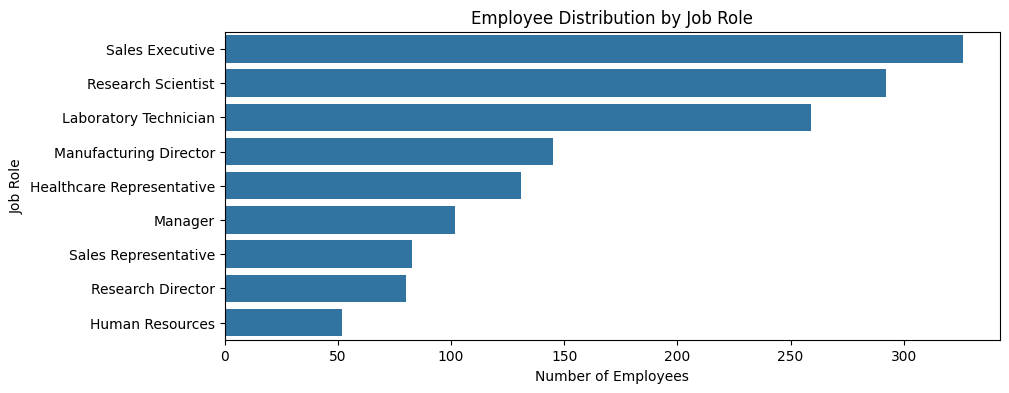

In [53]:
plt.figure(figsize=(10,4))
sns.countplot(data=df,y='JobRole')

plt.title('Employee Distribution by Job Role')
plt.ylabel('Job Role')
plt.xlabel('Number of Employees')

plt.show()

In [54]:
jobrole_summary = pd.DataFrame({
    'Employee Count': df['JobRole'].value_counts(),
    'Percentage': df['JobRole'].value_counts(normalize=True) * 100
})

jobrole_summary

,Employee Count,Percentage
JobRole,,
Sales Executive,326,22.176871
Research Scientist,292,19.863946
Laboratory Technician,259,17.619048
Manufacturing Director,145,9.863946
Healthcare Representative,131,8.911565
Manager,102,6.938776
Sales Representative,83,5.646259
Research Director,80,5.442177
Human Resources,52,3.537415


In [55]:
jobrole_summary['Employee Count'].min()

52

In [56]:
jobrole_summary['Employee Count'].max()

326

## 8. Attrition Analysis 🚨

A. Overall Attrition Analysis

In [57]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

In [58]:
attrition_counts = df['Attrition'].value_counts()

attrition_counts

,count
Attrition,
No,1233
Yes,237


In [59]:
attrition_percentage = df['Attrition'].value_counts(normalize=True)*100
attrition_percentage

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [60]:
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100

print("Overall Attrition Rate:", attrition_rate)

Overall Attrition Rate: 16.122448979591837


In [61]:
employees_left=(df['Attrition']=='Yes').sum()
print('employees left:',employees_left)

employees left: 237


In [62]:
employees_stayed=(df['Attrition']=='No').sum()
print('employees stayed:',employees_stayed)

employees stayed: 1233


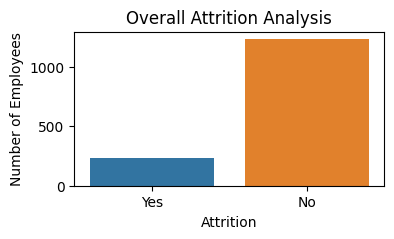

In [63]:
plt.figure(figsize=(4,2))
sns.countplot(data=df,x='Attrition',hue='Attrition')

plt.title('Overall Attrition Analysis')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

"The overall attrition rate is approximately 16.2%, with 237 employees leaving the organization out of 1470 total employees."

B. Attrition by Department


In [64]:
df.groupby('Department')['Attrition'].value_counts()

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

In [65]:
pd.crosstab(
    df['Department'],
    df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [66]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [67]:
department_attrition_rate = department_attrition['Yes']

department_attrition_rate

,Yes
Department,
Human Resources,19.047619
Research & Development,13.839750
Sales,20.627803


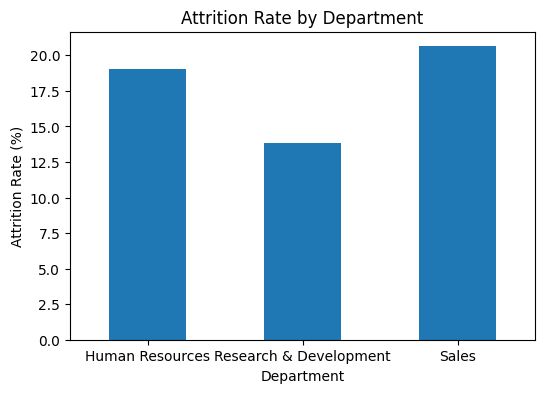

In [68]:
plt.figure(figsize=(6, 4))
department_attrition_rate.plot( kind='bar')

plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.xticks(rotation=0)

plt.show()

Department-level attrition: The Sales department has the highest attrition rate at approximately 20.6%, while Research & Development has the lowest at approximately 13.8%.

C. Attrition by Job Role


In [69]:
jobrole_attrition_counts=pd.crosstab(
    df['JobRole'],
    df['Attrition'])
jobrole_attrition_counts

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [70]:
jobrole_attrition=pd.crosstab(
    df['JobRole'],
    df['Attrition'], normalize='index')*100
jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [71]:
jobrole_attrition_rate = jobrole_attrition['Yes']

jobrole_attrition_rate

,Yes
JobRole,
Healthcare Representative,6.870229
Human Resources,23.076923
Laboratory Technician,23.938224
Manager,4.901961
Manufacturing Director,6.896552
Research Director,2.500000
Research Scientist,16.095890
Sales Executive,17.484663
Sales Representative,39.759036


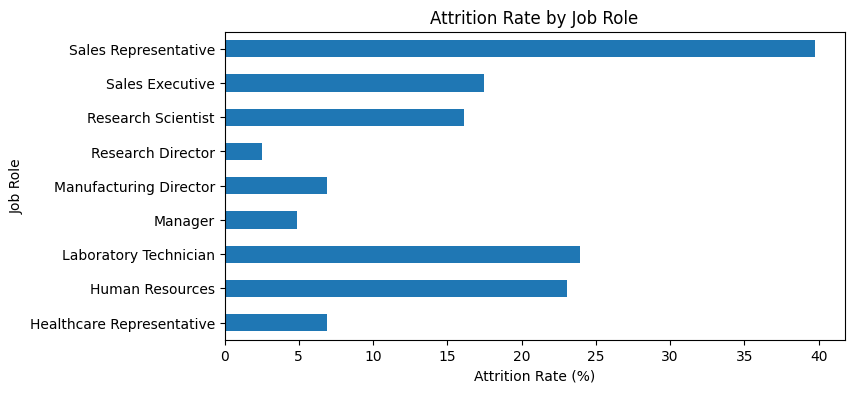

In [72]:
plt.figure(figsize=(8, 4))

jobrole_attrition_rate.plot(kind='barh')

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

plt.show()

In [73]:
highest_role = jobrole_attrition_rate.idxmax()
highest_rate = jobrole_attrition_rate.max()

print("Highest attrition role:", highest_role)
print("Attrition rate:", highest_rate)

Highest attrition role: Sales Representative
Attrition rate: 39.75903614457831


In [74]:
lowest_role = jobrole_attrition_rate.idxmin()
lowest_rate = jobrole_attrition_rate.min()

print("Lowest attrition role:", lowest_role)
print("Attrition rate:", lowest_rate)

Lowest attrition role: Research Director
Attrition rate: 2.5


In [75]:
difference = highest_rate - lowest_rate

print("Difference in attrition rates:", difference)

Difference in attrition rates: 37.25903614457831


Job-role attrition: Attrition varies across job roles, with Sales Representative showing the highest attrition rate at approximately 39.75%, while Research Director has the lowest rate at approximately 2.5%

D. Attrition by overtime

In [76]:
df['OverTime'].unique()

array(['Yes', 'No'], dtype=object)

In [77]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [78]:
overtime_attrition_counts = pd.crosstab(df['OverTime'], df['Attrition'])

overtime_attrition_counts

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [79]:
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'],normalize='index')*100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [80]:
overtime_attrition_rate = overtime_attrition['Yes']

overtime_attrition_rate

,Yes
OverTime,
No,10.436433
Yes,30.528846


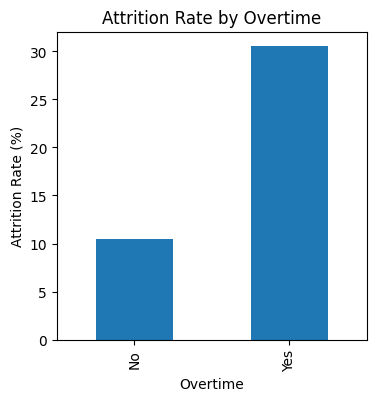

In [81]:
plt.figure(figsize=(4,4))
overtime_attrition_rate.plot(kind='bar')

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

plt.show()

In [82]:
difference = (overtime_attrition_rate['Yes'] - overtime_attrition_rate['No'])

print("Difference in attrition rate:", difference, "percentage points")

Difference in attrition rate: 20.092413516275 percentage points


Overtime and attrition: Employees who work overtime have the higher attrition rate, at approximately 30.5%, compared with Y% for the other group

E. Attrition by years at company

In [83]:
print("Mean:", df['YearsAtCompany'].mean())
print("Median:", df['YearsAtCompany'].median())
print("Minimum:", df['YearsAtCompany'].min())
print("Maximum:", df['YearsAtCompany'].max())

Mean: 7.0081632653061225
Median: 5.0
Minimum: 0
Maximum: 40


Text(0, 0.5, 'Number of Employees')

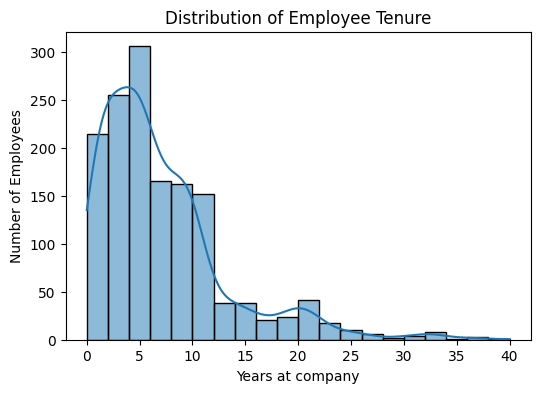

In [84]:
plt.figure(figsize=(6, 4))

sns.histplot(data=df,  x='YearsAtCompany',kde=True , bins=20)

plt.title('Distribution of Employee Tenure')
plt.xlabel('Years at company')
plt.ylabel('Number of Employees')

F. Job satisfaction vs attrition

In [85]:
df.groupby('Attrition')['JobSatisfaction'].mean()

,JobSatisfaction
Attrition,
No,2.778589
Yes,2.468354


In [86]:
df['JobSatisfaction'].unique()

array([4, 2, 3, 1])

In [87]:
df['JobSatisfaction'].value_counts().sort_index()

,count
JobSatisfaction,
1,289
2,280
3,442
4,459


In [88]:
job_satisfaction_attrition_counts= pd.crosstab(df['JobSatisfaction'],df['Attrition'])

job_satisfaction_attrition_counts

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [89]:
job_satisfaction_attrition = pd.crosstab(df['JobSatisfaction'],df['Attrition'],normalize='index')*100

job_satisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [90]:
job_satisfaction_attrition_rate = job_satisfaction_attrition['Yes']

job_satisfaction_attrition_rate

,Yes
JobSatisfaction,
1,22.837370
2,16.428571
3,16.515837
4,11.328976


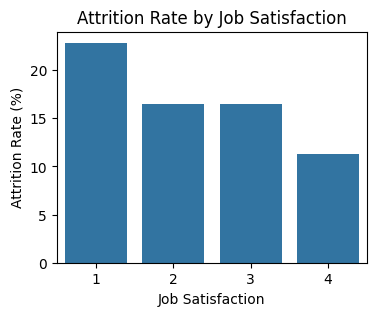

In [91]:
plt.figure(figsize=(4, 3))

sns.barplot(x=job_satisfaction_attrition_rate.index, y=job_satisfaction_attrition_rate.values)

plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Attrition Rate (%)')

plt.show()

The  job-satisfaction rate as 1 has the highest attrition rate at approximately 22%, while the rate as 4 has the lowest rate at approximately 11%.

G. Work-life balance vs attrition

In [92]:
df['WorkLifeBalance'].unique()

array([1, 3, 2, 4])

In [93]:
df.groupby('Attrition')['WorkLifeBalance'].mean()

,WorkLifeBalance
Attrition,
No,2.781022
Yes,2.658228


In [94]:
df['WorkLifeBalance'].value_counts()

,count
WorkLifeBalance,
3,893
2,344
4,153
1,80


In [95]:
worklife_attrition_counts = pd.crosstab(df['WorkLifeBalance'],df['Attrition'])

worklife_attrition_counts

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [96]:
worklife_attrition = pd.crosstab(df['WorkLifeBalance'],df['Attrition'],normalize='index')*100

worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [97]:
worklife_attrition_rate = worklife_attrition['Yes']

worklife_attrition_rate

,Yes
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


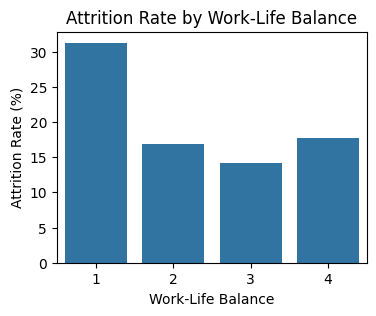

In [98]:
plt.figure(figsize=(4,3))
sns.barplot(x=worklife_attrition_rate.index, y=worklife_attrition_rate.values)

plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Attrition Rate (%)')

plt.show()

Work-life balance and attrition: Attrition varies across work-life balance categories, with rating=1 showing the highest attrition rate of approximately 31%, compared with 14% for rating=3 .

# Monthly income analysis

In [99]:
df['MonthlyIncome'].describe()

,MonthlyIncome
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


In [100]:
print("Mean Monthly Income:", df['MonthlyIncome'].mean())
print("Median Monthly Income:", df['MonthlyIncome'].median())

Mean Monthly Income: 6502.931292517007
Median Monthly Income: 4919.0


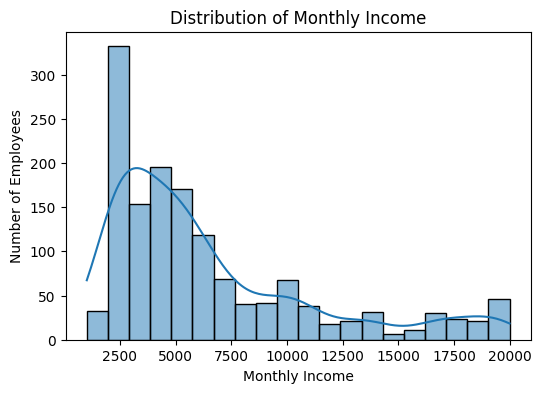

In [101]:
plt.figure(figsize=(6, 4))

sns.histplot(data=df, x='MonthlyIncome', kde=True)

plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')

plt.show()

In [102]:
df.groupby('Attrition')['MonthlyIncome'].mean()

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


# Correlation analysis

In [103]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Age', 'Education', 'DistanceFromHome', 'JobLevel', 'YearsAtCompany',
       'TotalWorkingYears', 'YearsInCurrentRole', 'MonthlyIncome',
       'PercentSalaryHike', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'PerformanceRating', 'JobInvolvement',
       'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'DailyRate'],
      dtype='object')

In [104]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Age,Education,DistanceFromHome,JobLevel,YearsAtCompany,TotalWorkingYears,YearsInCurrentRole,MonthlyIncome,PercentSalaryHike,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,JobInvolvement,EmployeeNumber,EmployeeCount,StandardHours,DailyRate
Age,1.000000,0.208034,-0.001686,0.509604,0.311309,0.680381,0.212901,0.497855,0.003634,0.010146,-0.004892,-0.021490,0.001904,0.029820,-0.010145,NaN,NaN,0.010661
Education,0.208034,1.000000,0.021042,0.101589,0.069114,0.148280,0.060236,0.094961,-0.011111,-0.027128,-0.011296,0.009819,-0.024539,0.042438,0.042070,NaN,NaN,-0.016806
DistanceFromHome,-0.001686,0.021042,1.000000,0.005303,0.009508,0.004628,0.018845,-0.017014,0.040235,-0.016075,-0.003669,-0.026556,0.027110,0.008783,0.032916,NaN,NaN,-0.004985
JobLevel,0.509604,0.101589,0.005303,1.000000,0.534739,0.782208,0.389447,0.950300,-0.034730,0.001212,-0.001944,0.037818,-0.021222,-0.012630,-0.018519,NaN,NaN,0.002966
YearsAtCompany,0.311309,0.069114,0.009508,0.534739,1.000000,0.628133,0.758754,0.514285,-0.035991,0.001458,-0.003803,0.012089,0.003435,-0.021355,-0.011240,NaN,NaN,-0.034055
TotalWorkingYears,0.680381,0.148280,0.004628,0.782208,0.628133,1.000000,0.460365,0.772893,-0.020608,-0.002693,-0.020185,0.001008,0.006744,-0.005533,-0.014365,NaN,NaN,0.014515
YearsInCurrentRole,0.212901,0.060236,0.018845,0.389447,0.758754,0.460365,1.000000,0.363818,-0.001520,0.018007,-0.002305,0.049856,0.034986,0.008717,-0.008416,NaN,NaN,0.009932
MonthlyIncome,0.497855,0.094961,-0.017014,0.950300,0.514285,0.772893,0.363818,1.000000,-0.027269,-0.006259,-0.007157,0.030683,-0.017120,-0.015271,-0.014829,NaN,NaN,0.007707
PercentSalaryHike,0.003634,-0.011111,0.040235,-0.034730,-0.035991,-0.020608,-0.001520,-0.027269,1.000000,-0.031701,0.020002,-0.003280,0.773550,-0.017205,-0.012944,NaN,NaN,0.022704
EnvironmentSatisfaction,0.010146,-0.027128,-0.016075,0.001212,0.001458,-0.002693,0.018007,-0.006259,-0.031701,1.000000,-0.006784,0.027627,-0.029548,-0.008278,0.017621,NaN,NaN,0.018355


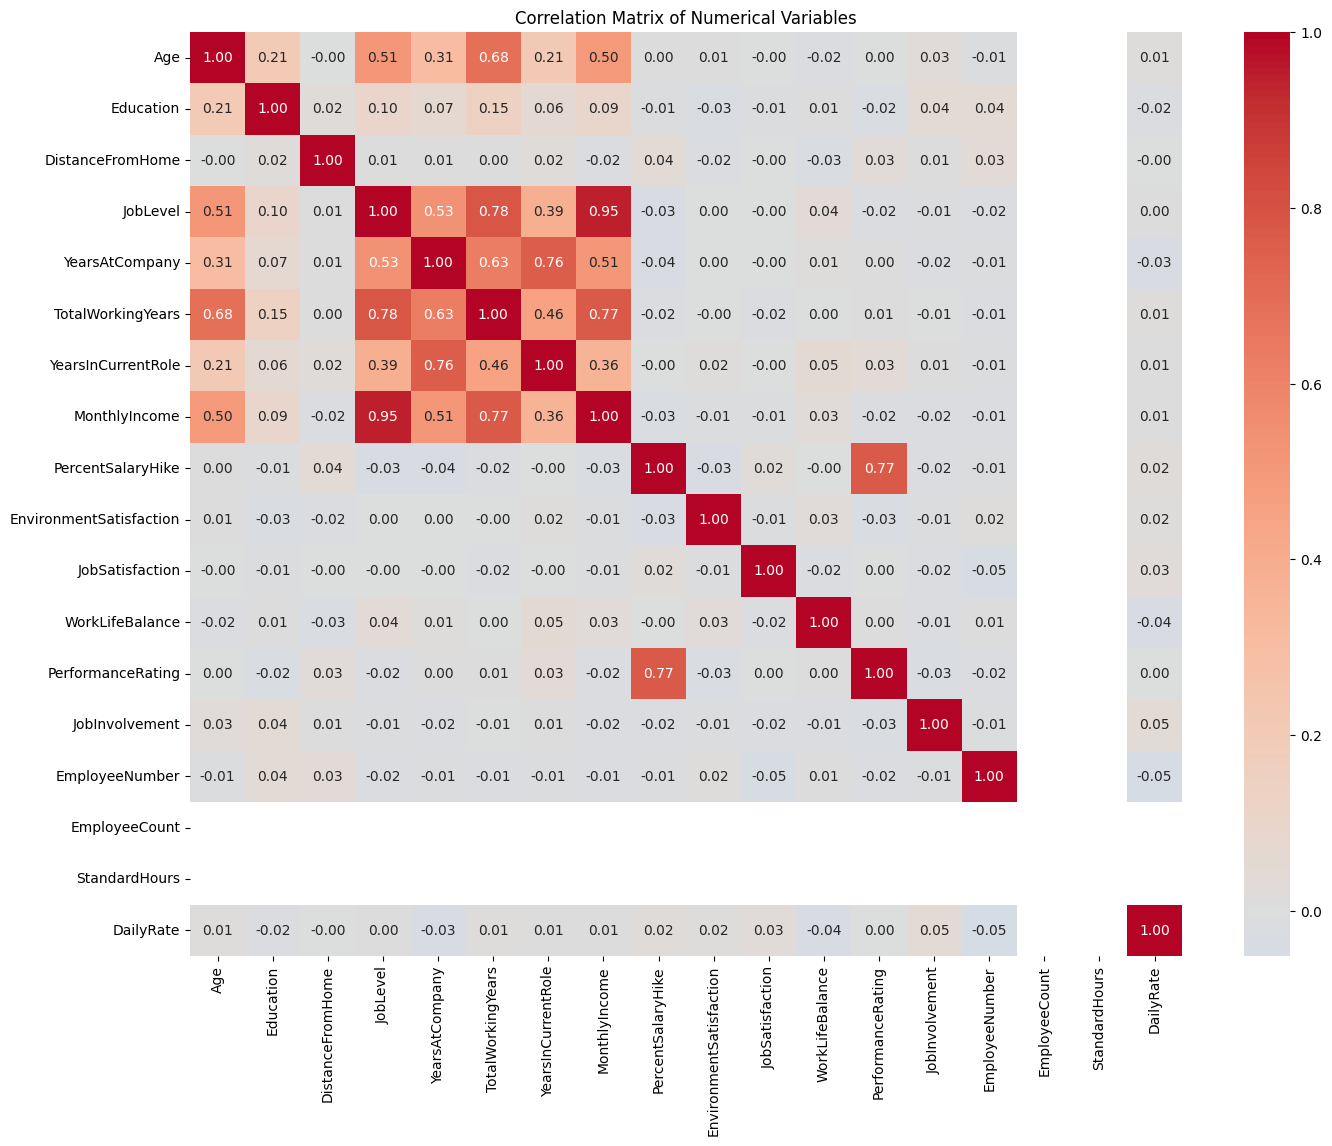

In [105]:
plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [106]:
corr_pairs = correlation_matrix.unstack()

corr_pairs

Age        Age                 1.000000
           Education           0.208034
           DistanceFromHome   -0.001686
           JobLevel            0.509604
           YearsAtCompany      0.311309
                                 ...   
DailyRate  JobInvolvement      0.046135
           EmployeeNumber     -0.050990
           EmployeeCount            NaN
           StandardHours            NaN
           DailyRate           1.000000
Length: 324, dtype: float64

In [107]:
corr_pairs.sort_values(ascending=True).head(15)

DailyRate                EmployeeNumber            -0.050990
EmployeeNumber           DailyRate                 -0.050990
                         JobSatisfaction           -0.046247
JobSatisfaction          EmployeeNumber            -0.046247
WorkLifeBalance          DailyRate                 -0.037848
DailyRate                WorkLifeBalance           -0.037848
YearsAtCompany           PercentSalaryHike         -0.035991
PercentSalaryHike        YearsAtCompany            -0.035991
                         JobLevel                  -0.034730
JobLevel                 PercentSalaryHike         -0.034730
YearsAtCompany           DailyRate                 -0.034055
DailyRate                YearsAtCompany            -0.034055
PercentSalaryHike        EnvironmentSatisfaction   -0.031701
EnvironmentSatisfaction  PercentSalaryHike         -0.031701
PerformanceRating        EnvironmentSatisfaction   -0.029548
dtype: float64

In [111]:
corr_pairs.sort_values(ascending=False).head(15)

,,0
Age,Age,1.0
Education,Education,1.0
JobLevel,JobLevel,1.0
DistanceFromHome,DistanceFromHome,1.0
YearsInCurrentRole,YearsInCurrentRole,1.0
MonthlyIncome,MonthlyIncome,1.0
TotalWorkingYears,TotalWorkingYears,1.0
YearsAtCompany,YearsAtCompany,1.0
PerformanceRating,PerformanceRating,1.0
JobInvolvement,JobInvolvement,1.0


# Key Findings

Based on the exploratory analysis, the following key patterns were identified:

### 1. Overall Attrition

The overall employee attrition rate was approximately **16.1%**, indicating that a meaningful proportion of employees in the dataset had left the organization.

### 2. Department

The **Sales ** department recorded the highest attrition rate at approximately **20.6%**.

### 3. Job Role

The **Sales Representative** role showed the highest attrition rate at approximately **39.7%**, indicating that attrition varies considerably across job roles.

### 4. Overtime

Employees working overtime had an attrition rate of approximately **30.5%**, compared with **10.4%** among employees who did not work overtime.

### 5. Age

The **Younger** age group showed the highest attrition rate at approximately **38.4%**.

### 6. Tenure

Employees in the **short tenure**  category showed the highest attrition rate at approximately **22.4%**.

### 7. Job Satisfaction

Attrition varied across job-satisfaction levels, with the **rating=1** group recording the highest attrition rate.

### 8. Monthly Income

Employees who left had a **lower** average monthly income compared with employees who stayed.

> **Note:** These findings represent associations observed in the dataset and should not be interpreted as evidence of causation.
